In [15]:
# Cell 1: Import libraries and read dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [16]:
df = pd.read_csv("final_dataset.csv")
df.head()

,TransactionID,Date,Time,Company,LocationID,City,FuelType,Quantity_Liters,Price_per_Litre,Total_Amount,PaymentMethod,VehicleType,LoyaltyCardUsed,PumpNumber,EmployeeID
0,TXN001,03-01-2024,05:44:00,HP,delhi-pump-04,delhi,petrol,26.30,94.46,2484.30,UPI,car,No,3,E-DEL-4
1,TXN002,04-02-2025,21:08:00,IOCL,pune-pump-01,pune,diesel,42.89,87.57,3755.88,Card,car,Yes,5,E-PUN-3
2,TXN003,25-08-2024,06:39:00,BPCL,mumbai-pump-02,mumbai,diesel,10.42,88.11,918.11,Card,bike,Yes,1,E-MUM-2
3,TXN004,05-01-2025,15:20:00,IOCL,bangalore-pump-07,bangalore,petrol,14.49,95.10,1378.00,Cash,bike,No,2,E-BAN-1
4,TXN005,09-04-2025,19:52:00,HP,mumbai-pump-02,mumbai,diesel,39.37,87.21,3433.46,Cash,car,No,5,E-MUM-5


In [17]:
# Parse dates
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
df = df.dropna(subset=['Date'])

# ============================================
# Cell 2: Aggregate at requested granularity
# ============================================
key_cols = ['Date','Company','FuelType','PaymentMethod','City']
daily_sales = df.groupby(key_cols, as_index=False)['Total_Amount'].sum()
daily_sales.rename(columns={'Total_Amount':'Daily_Total_Amount'}, inplace=True)

In [18]:
# Cell 3: Feature engineering
# ============================================
cal = daily_sales.copy()
cal['Year'] = cal['Date'].dt.year
cal['Month'] = cal['Date'].dt.month
cal['Day'] = cal['Date'].dt.day
cal['DayOfWeek'] = cal['Date'].dt.dayofweek
cal['IsWeekend'] = cal['DayOfWeek'].isin([5,6]).astype(int)
cal['IsRepublicDay'] = ((cal['Month']==1) & (cal['Day']==26)).astype(int)

# Prior years mean per combo + day
history_key = ['Company','FuelType','PaymentMethod','City','Day']
hist_stats = (
    cal.groupby(history_key+['Year'], as_index=False)['Daily_Total_Amount']
       .mean()
       .rename(columns={'Daily_Total_Amount':'DayMean_ThisYear'})
)

def prior_year_mean(group):
    group = group.sort_values('Year')
    group['DayMean_PriorYears'] = group['DayMean_ThisYear'].shift().expanding().mean()
    return group

hist_stats = hist_stats.groupby(history_key, group_keys=False).apply(prior_year_mean)

cal = cal.merge(hist_stats[history_key+['Year','DayMean_PriorYears']],
                on=history_key+['Year'], how='left')

# Fallback global mean
fallback = (
    cal.groupby(history_key, as_index=False)['Daily_Total_Amount']
       .mean()
       .rename(columns={'Daily_Total_Amount':'DayMean_Global'})
)
cal = cal.merge(fallback, on=history_key, how='left')
cal['DayMean_PriorYears'] = cal['DayMean_PriorYears'].fillna(cal['DayMean_Global'])

C:\Users\farook\AppData\Local\Temp\ipykernel_9768\287075654.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hist_stats = hist_stats.groupby(history_key, group_keys=False).apply(prior_year_mean)


In [19]:
# Cell 4: Train (Jan 2024) and Test (Jan 2025)
# ============================================
train_mask = (cal['Year']==2024) & (cal['Month']==1) & (cal['Day']<=30)
test_mask  = (cal['Year']==2025) & (cal['Month']==1) & (cal['Day']<=30)

train_df = cal.loc[train_mask].copy()
test_df  = cal.loc[test_mask].copy()

cat_features = ['Company','FuelType','PaymentMethod','City']
num_features = ['Year','Month','Day','DayOfWeek','IsWeekend','IsRepublicDay','DayMean_PriorYears']
target_col = 'Daily_Total_Amount'

X_train, y_train = train_df[cat_features+num_features], train_df[target_col]
X_test, y_test   = test_df[cat_features+num_features], test_df[target_col]

In [20]:
# Cell 5: Pipeline (OneHot + XGBoost)
# ============================================
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num', 'passthrough', num_features)
])

reg_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

pipe = Pipeline([('preprocess', preprocess), ('model', reg_model)])
pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
# Cell 6: Evaluation on Jan 2025
# ============================================
y_pred = pipe.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(((y_test-y_pred)**2).mean())
r2 = r2_score(y_test, y_pred)

print("----- Evaluation on Jan 2025 -----")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")

----- Evaluation on Jan 2025 -----
MAE: 447.99
RMSE: 625.89
R2: 0.7651


In [22]:
#Forecast Jan 1 2026 – jan 30 2026
forecast_dates = pd.date_range('2026-01-01','2026-01-30')
companies = sorted(df['Company'].unique())
fuel_types = sorted(df['FuelType'].unique())
payment_methods = sorted(df['PaymentMethod'].unique())
cities = sorted(df['City'].unique())

future_grid = pd.DataFrame(
    [(date,c,f,p,ci) for date in forecast_dates
                     for c in companies
                     for f in fuel_types
                     for p in payment_methods
                     for ci in cities],
    columns=['Date','Company','FuelType','PaymentMethod','City']
)

future_grid['Year'] = future_grid['Date'].dt.year
future_grid['Month'] = future_grid['Date'].dt.month
future_grid['Day'] = future_grid['Date'].dt.day
future_grid['DayOfWeek'] = future_grid['Date'].dt.dayofweek
future_grid['IsWeekend'] = future_grid['DayOfWeek'].isin([5,6]).astype(int)
future_grid['IsRepublicDay'] = ((future_grid['Month']==1) & (future_grid['Day']==26)).astype(int)

# Prior years mean for Jan 1–30
same_days_hist = cal[(cal['Month']==1) & (cal['Day']<=30)].copy()
prior_means = (
    same_days_hist.groupby(['Company','FuelType','PaymentMethod','City','Day'], as_index=False)['Daily_Total_Amount']
                 .mean()
                 .rename(columns={'Daily_Total_Amount':'DayMean_PriorYears'})
)
combo_global = (
    cal.groupby(['Company','FuelType','PaymentMethod','City'], as_index=False)['Daily_Total_Amount']
       .mean()
       .rename(columns={'Daily_Total_Amount':'DayMean_Global'})
)

future_grid = future_grid.merge(prior_means, on=['Company','FuelType','PaymentMethod','City','Day'], how='left')
future_grid = future_grid.merge(combo_global, on=['Company','FuelType','PaymentMethod','City'], how='left')
future_grid['DayMean_PriorYears'] = future_grid['DayMean_PriorYears'].fillna(future_grid['DayMean_Global']).fillna(0.0)

X_future = future_grid[cat_features+num_features]
future_grid['Predicted_Daily_Total_Amount'] = pipe.predict(X_future)

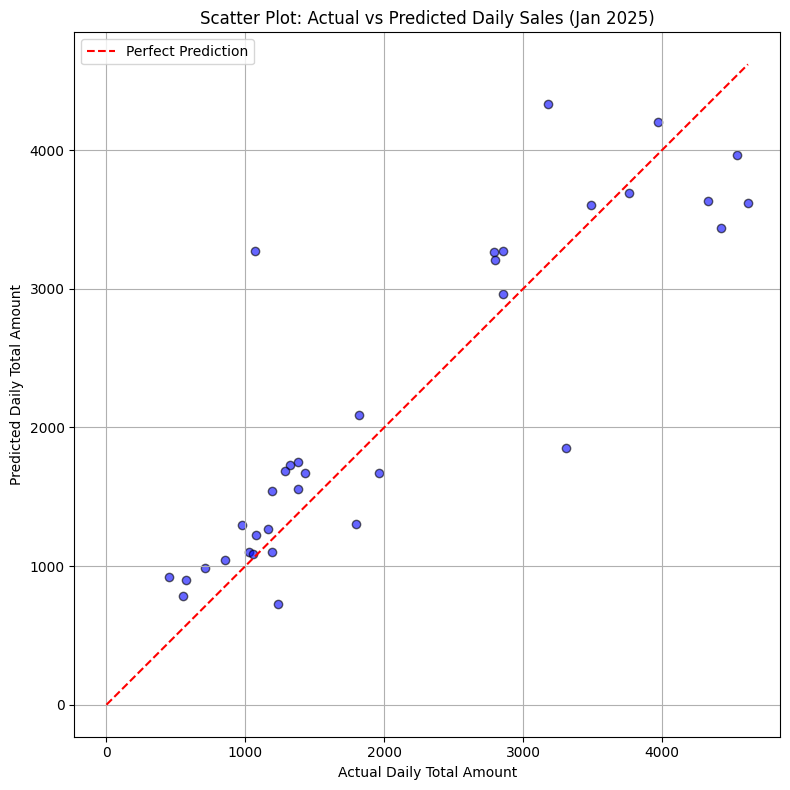

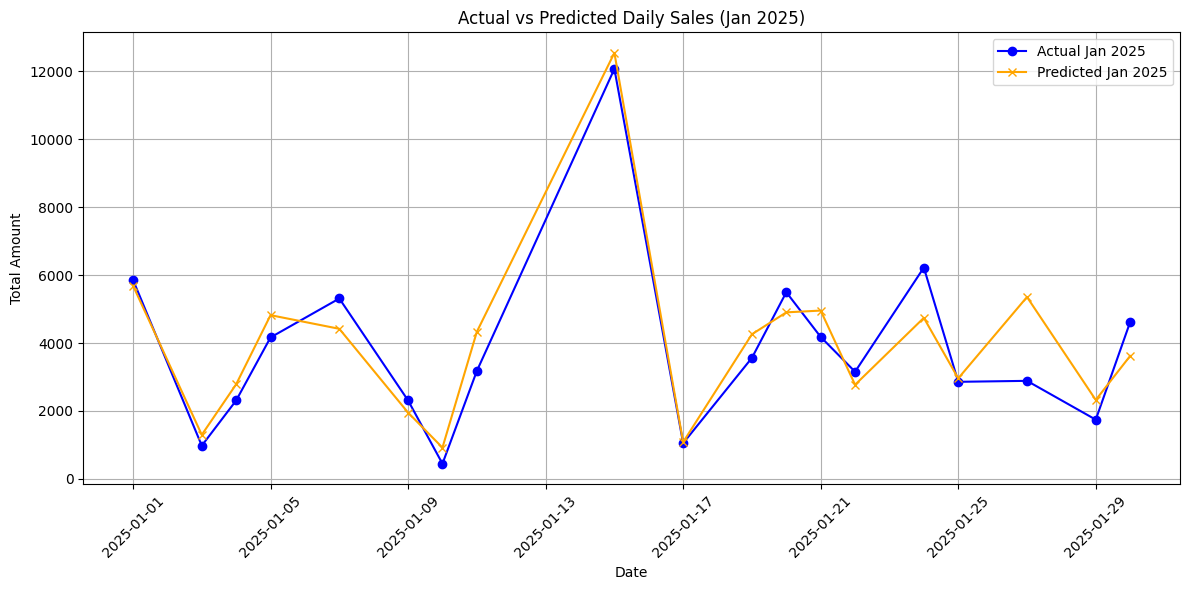

In [ ]:


# Scatter Plot: Actual vs Predicted (Jan 2025)
plt.figure(figsize=(8,8))
plt.scatter(test_results['Actual_Daily_Total_Amount'],
            test_results['Predicted_Daily_Total_Amount'],
            alpha=0.6, color='blue', edgecolor='k')
max_val = max(test_results['Actual_Daily_Total_Amount'].max(),
              test_results['Predicted_Daily_Total_Amount'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')

plt.title("Scatter Plot: Actual vs Predicted Daily Sales (Jan 2025)")
plt.xlabel("Actual Daily Total Amount")
plt.ylabel("Predicted Daily Total Amount")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
# Export full forecast
future_grid.to_csv("forecast_breakdown_2026-01-01_to_2026-01-30.csv", index=False)